# Titanic Survival Prediction — Data Cleaning & Basic ML
**Skill Nexis ML & AI Internship — Week 1 Project**

**Author:** Prince Kumar

This notebook covers the Week 1 fundamentals of a Machine Learning workflow:
loading data, exploring it, cleaning it, encoding categorical features, visualizing
a key feature, and training a simple **Logistic Regression** model to predict
passenger survival on the Titanic.

The notebook is self-contained — it downloads the dataset from a public URL, so it
can be run top-to-bottom on any machine without manual setup.

## 1. Import Libraries

We import the core libraries needed for this project:
- **pandas** for loading and manipulating tabular data
- **numpy** for numerical operations
- **matplotlib** / **seaborn** for visualization
- **scikit-learn** for splitting data, encoding, training, and evaluating the model

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

sns.set(style="whitegrid")
%matplotlib inline

## 2. Load the Titanic Dataset

We use a publicly available copy of the classic Titanic dataset (hosted on GitHub).
Using a public URL keeps the notebook self-contained — no manual file download or
machine-specific paths are required.

In [2]:
DATA_URL = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"

df = pd.read_csv(DATA_URL)
print("Dataset loaded successfully!")
print(f"Shape: {df.shape}")

Dataset loaded successfully!
Shape: (891, 12)


## 3. Inspect the Dataset

Before doing anything else, we take a first look at the data: its first few rows,
its shape (rows x columns), the data types of each column, and basic summary
statistics for the numerical columns.

In [3]:
# First few rows
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [4]:
# Shape of the dataset (rows, columns)
print(f"The dataset has {df.shape[0]} rows and {df.shape[1]} columns.")

The dataset has 891 rows and 12 columns.


In [5]:
# Column information: data types and non-null counts
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


In [6]:
# Statistical summary of numerical columns
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


## 4. Identify Missing Values

Real-world datasets are rarely complete. We check each column for missing values
so we know exactly what needs to be cleaned before modeling.

In [7]:
missing_values = df.isnull().sum()
missing_percent = (df.isnull().sum() / len(df)) * 100

missing_summary = pd.DataFrame({
    "Missing Values": missing_values,
    "Percentage (%)": missing_percent.round(2)
})

missing_summary[missing_summary["Missing Values"] > 0].sort_values(
    by="Missing Values", ascending=False
)

,Missing Values,Percentage (%)
Cabin,687,77.10
Age,177,19.87
Embarked,2,0.22


## 5. Data Cleaning

We handle the missing data column by column:

- **Age**: a numerical column with a moderate amount of missing data. We fill missing
  values with the **median** age, since median is robust to outliers (better than mean
  for a slightly skewed distribution like age).
- **Embarked**: only a couple of values are missing, so we fill them with the **mode**
  (the most frequently occurring port of embarkation).
- **Cabin**: the vast majority of values are missing, so instead of guessing individual
  cabins we create a simple binary feature `Has_Cabin` (1 if cabin info is known, 0
  otherwise), then drop the original high-missing `Cabin` column.
- **Unnecessary columns**: `PassengerId`, `Name`, and `Ticket` are identifiers/free-text
  fields that do not carry useful predictive signal for a simple baseline model, so we
  drop them to keep preprocessing simple and understandable.

In [8]:
# Fill missing Age with the median age
df["Age"] = df["Age"].fillna(df["Age"].median())

# Fill missing Embarked with the most common port (mode)
df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode()[0])

# Cabin has too many missing values to impute meaningfully.
# Instead, create a simple binary feature indicating whether cabin info exists.
df["Has_Cabin"] = df["Cabin"].notnull().astype(int)
df = df.drop(columns=["Cabin"])

# Drop columns that are identifiers / free text and not useful for a simple model
df = df.drop(columns=["PassengerId", "Name", "Ticket"])

print("Missing values after cleaning:")
df.isnull().sum()

Missing values after cleaning:


Survived     0
Pclass       0
Sex          0
Age          0
SibSp        0
Parch        0
Fare         0
Embarked     0
Has_Cabin    0
dtype: int64

## 6. Encode Categorical Features

Machine learning models need numerical input, so we convert categorical columns:

- **Sex**: converted to numeric using label encoding (`male` = 1, `female` = 0).
- **Embarked**: converted using **one-hot encoding**, since it has more than two
  categories with no natural order (`C`, `Q`, `S`).

In [9]:
# Label encode Sex (binary category)
le = LabelEncoder()
df["Sex"] = le.fit_transform(df["Sex"])  # female -> 0, male -> 1

# One-hot encode Embarked (drop_first avoids redundant columns)
df = pd.get_dummies(df, columns=["Embarked"], prefix="Embarked", drop_first=True)

df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Has_Cabin,Embarked_Q,Embarked_S
0,0,3,1,22.0,1,0,7.2500,0,False,True
1,1,1,0,38.0,1,0,71.2833,1,False,False
2,1,3,0,26.0,0,0,7.9250,0,False,True
3,1,1,0,35.0,1,0,53.1000,1,False,True
4,0,3,1,35.0,0,0,8.0500,0,False,True


## 7. Simple Feature Engineering

To keep preprocessing simple and understandable (as required for Week 1), we add one
small, intuitive feature:

- **FamilySize**: combines `SibSp` (siblings/spouses aboard) and `Parch`
  (parents/children aboard) plus the passenger themself, giving a single measure of
  how large a passenger's family group was.

In [10]:
df["FamilySize"] = df["SibSp"] + df["Parch"] + 1
df[["SibSp", "Parch", "FamilySize"]].head()

,SibSp,Parch,FamilySize
0,1,0,2
1,1,0,2
2,0,0,1
3,1,0,2
4,0,0,1


## 8. Visualize the Age Distribution

We plot the distribution of passenger ages to understand the spread of this feature
after cleaning (missing values have already been filled with the median).

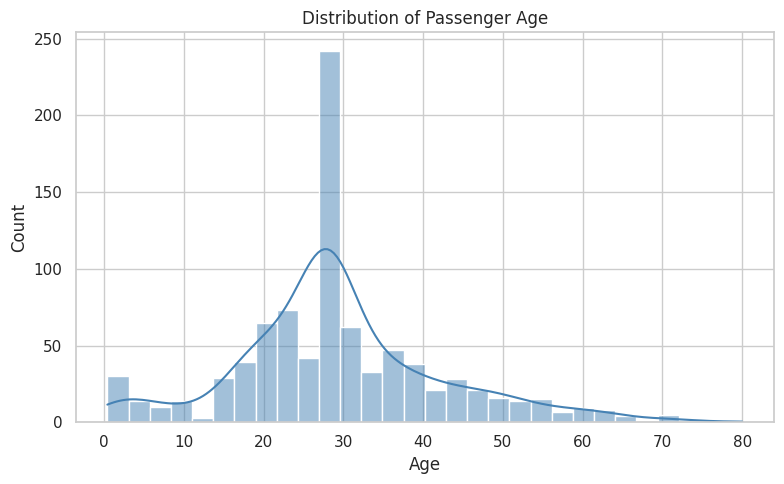

In [11]:
plt.figure(figsize=(8, 5))
sns.histplot(df["Age"], bins=30, kde=True, color="steelblue")
plt.title("Distribution of Passenger Age")
plt.xlabel("Age")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

## 9. Save the Cleaned Dataset

We save the cleaned and preprocessed dataset to `data/titanic_cleaned.csv` so it can
be reused without repeating the cleaning steps.

In [12]:
output_dir = os.path.join("..", "data")
os.makedirs(output_dir, exist_ok=True)

output_path = os.path.join(output_dir, "titanic_cleaned.csv")
df.to_csv(output_path, index=False)

print(f"Cleaned dataset saved to: {output_path}")
df.head()

Cleaned dataset saved to: ../data/titanic_cleaned.csv


,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Has_Cabin,Embarked_Q,Embarked_S,FamilySize
0,0,3,1,22.0,1,0,7.2500,0,False,True,2
1,1,1,0,38.0,1,0,71.2833,1,False,False,2
2,1,3,0,26.0,0,0,7.9250,0,False,True,1
3,1,1,0,35.0,1,0,53.1000,1,False,True,2
4,0,3,1,35.0,0,0,8.0500,0,False,True,1


## 10. Define Features (X) and Target (y)

The target variable is `Survived` (1 = survived, 0 = did not survive). All remaining
columns are used as input features.

In [13]:
X = df.drop(columns=["Survived"])
y = df["Survived"]

print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")
X.columns.tolist()

Features shape: (891, 10)
Target shape: (891,)


['Pclass',
 'Sex',
 'Age',
 'SibSp',
 'Parch',
 'Fare',
 'Has_Cabin',
 'Embarked_Q',
 'Embarked_S',
 'FamilySize']

## 11. Split Data into Training and Testing Sets

We split the data into 80% training data and 20% testing data. `random_state` is set
for reproducibility, and `stratify=y` keeps the survival ratio consistent between the
train and test sets.

In [14]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set size: {X_train.shape[0]}")
print(f"Testing set size: {X_test.shape[0]}")

Training set size: 712
Testing set size: 179


## 12. Train a Logistic Regression Model

Logistic Regression is a simple, well-understood classification algorithm and a great
baseline for a binary classification problem like survival prediction.

In [15]:
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

print("Model training complete.")

Model training complete.


## 13. Evaluate the Model

We evaluate the trained model on the unseen test set using **accuracy** — the
proportion of correctly predicted outcomes — along with a confusion matrix and
classification report for a fuller picture.

In [16]:
y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print(f"Model Accuracy: {accuracy:.4f} ({accuracy * 100:.2f}%)")

Model Accuracy: 0.8045 (80.45%)


In [17]:
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print()
print("Classification Report:")
print(classification_report(y_test, y_pred))

Confusion Matrix:
[[96 14]
 [21 48]]

Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.87      0.85       110
           1       0.77      0.70      0.73        69

    accuracy                           0.80       179
   macro avg       0.80      0.78      0.79       179
weighted avg       0.80      0.80      0.80       179



## Summary

In this notebook we:
1. Loaded the Titanic dataset directly from a public source.
2. Explored its shape, structure, and summary statistics.
3. Cleaned missing values in `Age`, `Embarked`, and `Cabin`.
4. Encoded categorical features (`Sex`, `Embarked`).
5. Engineered a simple `FamilySize` feature.
6. Visualized the age distribution.
7. Trained a baseline Logistic Regression model and evaluated its accuracy.

This forms a solid Week 1 foundation for the Skill Nexis ML & AI internship, covering
the full basic pipeline: **load → explore → clean → encode → visualize → train →
evaluate**.